In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [8]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.mappers import ParityMapper

def H2_qubits_custom(bond_length):
    atom_string = f"H 0 0 0; H 0 0 {bond_length}"
    
    # Definisi basis STO-1G kustom
    # Struktur: [ [angular_momentum, (exponent, coefficient)] ]
    # Zeta (zeta) 0.4166123 dikonversi ke eksponen Gaussian (alpha) 
    # alpha = (2 * zeta^2) / pi untuk pendekatan STO-1G sederhana
    # Namun biasanya PySCF menerima alpha langsung. 
    # Jika 0.4166123 adalah nilai alpha (exponent):
    custom_basis = {
        'H': [[0, [0.4166123, 1.0]]]
    }

    driver = PySCFDriver(
        atom=atom_string,
        basis=custom_basis, # Menggunakan dict kustom
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    )

    es_problem = driver.run()
    second_q_op = es_problem.hamiltonian.second_q_op()

    mapper = ParityMapper(num_particles=es_problem.num_particles)
    qubit_op = mapper.map(second_q_op)
    
    return qubit_op.to_list()

bondlengths = [0.25, 0.45, 0.65, 0.725, 0.80, 1.50, 2.50, 3.00]
data = {}
for r in bondlengths:
    data[float(r)] = H2_qubits_custom(r)

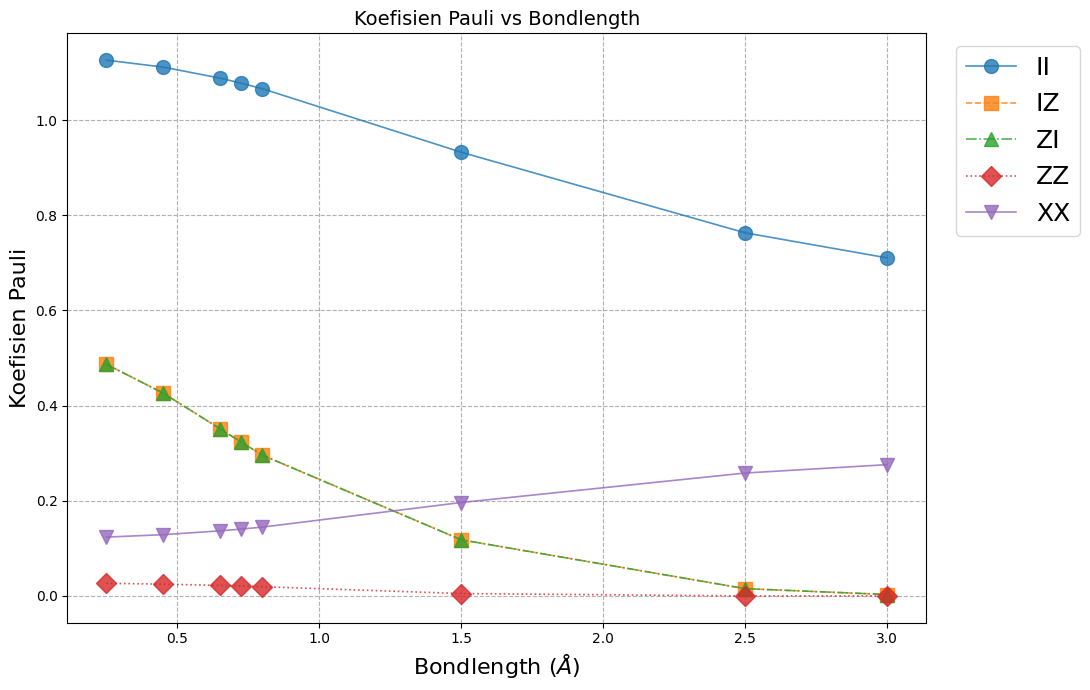

In [9]:

# pilih string yang ingin diplot di grafik yang sama
opsi_terms = ['II', 'IZ', 'ZI', 'ZZ', 'XX']
 # ganti sesuai pilihanmu
import itertools

ondlengths = np.abs(sorted(data.keys()))

# --- STRATEGI DOUBLE ENCODING ---
# Menyiapkan variasi marker dan gaya garis
markers = itertools.cycle(['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', '8', 'X'])
line_styles = itertools.cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(11, 7)) # Sedikit lebih besar untuk menampung banyak informasi

for term in opsi_terms:
    values = []
    for b in bondlengths:
        term_dict = dict(data[b])
        val = term_dict.get(term, 0)
        absolute_value = abs(val.real)
        values.append(absolute_value)
    
    # Tetap biarkan warna otomatis (atau tentukan sendiri)
    # Namun tambahkan marker dan linestyle yang unik untuk tiap term
    plt.plot(bondlengths, values, 
             label=term, 
             marker=next(markers), 
             linestyle=next(line_styles),
             markersize=10, 
             linewidth=1.2,
             alpha=0.8) # Transparansi membantu melihat tumpukan garis

plt.xlabel(r'Bondlength ($\AA$)', fontsize=16)
plt.ylabel('Koefisien Pauli', fontsize=16)
plt.title('Koefisien Pauli vs Bondlength', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=1)

# Membuat legend lebih rapi dengan 2 kolom agar tidak terlalu tinggi
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=18, ncol=1, frameon=True)

plt.tight_layout()
plt.show()

Test data

In [4]:
import os
import pandas as pd
import re
def load_all_tests(type_folder, # Jadikan ini argumen wajib atau opsional
                   base_dir='../hasil_eksperimenV13_parity',
                   rel_path=('ml_training', 'predict_data', 'predicted_data_1.csv')):
    
    # Gabungkan base_dir dengan type_folder
    full_base_path = os.path.join(base_dir, type_folder)
    
    # Fungsi pembantu untuk natural sorting
    def natural_key(text):
        return [int(c) if c.isdigit() else c for c in re.split(r'(\d+)', text)]

    dataframes = []
    
    # Pastikan folder ada sebelum listdir
    if not os.path.exists(full_base_path):
        raise FileNotFoundError(f"Folder tidak ditemukan: {full_base_path}")

    dir_list = sorted(os.listdir(full_base_path), key=natural_key)

    for test_dir in dir_list:
        csv_path = os.path.join(full_base_path, test_dir, *rel_path)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df['dataset'] = test_dir
            dataframes.append(df)
            
    if not dataframes:
        raise FileNotFoundError(f"Tidak ada file di {full_base_path}")

    full_df = pd.concat(dataframes, ignore_index=True)
    
    # Tetap gunakan categorical agar urutan J-S-1, J-S-2 dst tetap terjaga
    full_df['dataset'] = pd.Categorical(full_df['dataset'], categories=dir_list, ordered=True)
    
    return full_df

ALL

In [5]:
rf_table = load_all_tests('all')
rf_table["pred_abs_err"] = (rf_table["RF_energy"] - rf_table["ideal_energy"]).abs()
rf_table = rf_table.groupby("dataset", observed=True)["pred_abs_err"].mean()

rf_table

dataset
P-A-1    0.013525
Name: pred_abs_err, dtype: float64

single

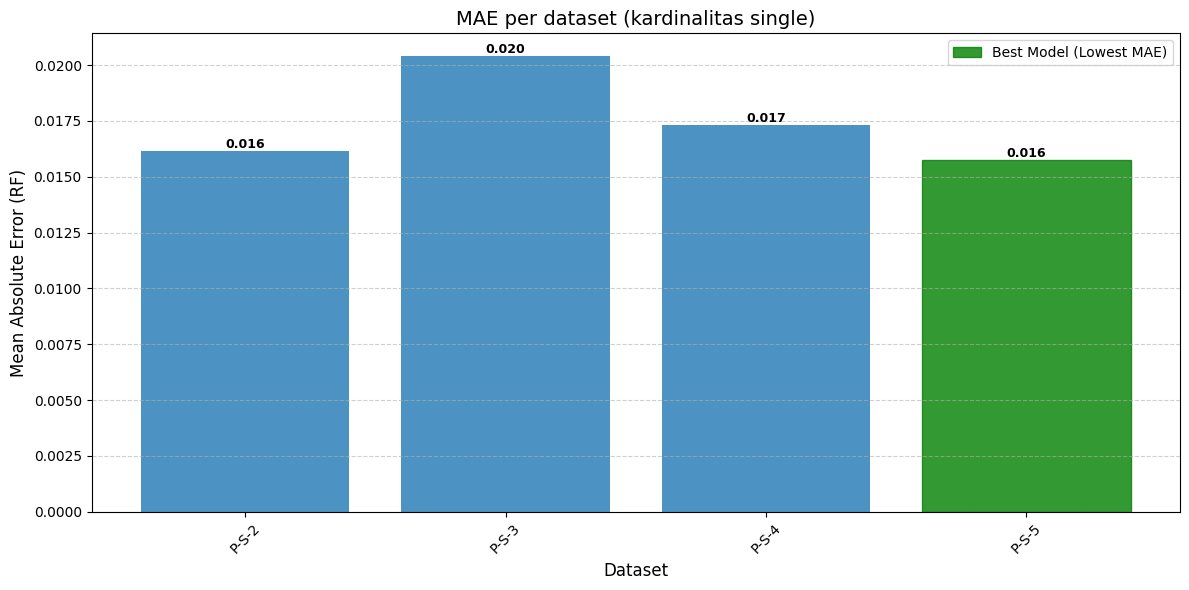

In [6]:
import matplotlib.pyplot as plt

# --- 1. PROSES DATA (Dari kode kedua) ---
df_all = load_all_tests(type_folder='single') 
df_all = df_all[~df_all['dataset'].isin(['P-S-1'])]

# Hitung mean absolute error RF per dataset
df_all["pred_abs_err"] = (df_all["RF_energy"] - df_all["ideal_energy"]).abs()
rf_means = df_all.groupby("dataset", observed=True)["pred_abs_err"].mean()

# Ubah Series menjadi DataFrame agar sesuai dengan logika 'final_score' di kode referensi
plot_data = rf_means.reset_index()
plot_data.columns = ['dataset', 'mae']

# --- 2. VISUALISASI (Menggunakan metode kode pertama) ---
plt.figure(figsize=(12, 6))
bars = plt.bar(plot_data['dataset'], plot_data['mae'], color='#1f77b4', alpha=0.8)

# Highlight Best Model (Nilai MAE Terendah)
if not plot_data.empty:
    # Cari index dengan nilai MAE terendah
    min_idx = plot_data['mae'].idxmin() 
    
    # Warnai bar tersebut dengan hijau
    bars[min_idx].set_color('green')
    bars[min_idx].set_label('Best Model (Lowest MAE)')

# Menambahkan label nilai di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.3f}", 
             va='bottom', ha='center', fontsize=9, fontweight='bold')

# Styling Tambahan
plt.xlabel("Dataset", fontsize=12)
plt.ylabel("Mean Absolute Error (RF)", fontsize=12)
plt.title("MAE per dataset (kardinalitas single)", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

# Menampilkan legend (penting untuk label 'Best Model')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
rf_table = load_all_tests('single')
rf_table["pred_abs_err"] = (rf_table["RF_energy"] - rf_table["ideal_energy"]).abs()
rf_table = rf_table.groupby("dataset", observed=True)["pred_abs_err"].mean()

rf_table.sort_values()

dataset
P-S-2    0.016174
P-S-5    0.016296
P-S-4    0.017058
P-S-3    0.020874
P-S-1    0.809952
Name: pred_abs_err, dtype: float64

Dual

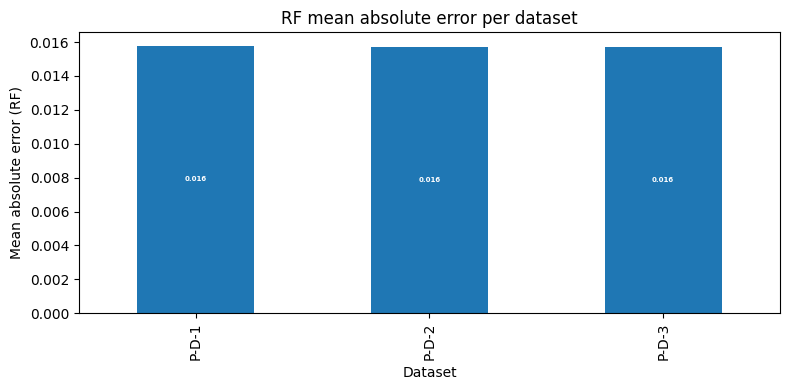

In [12]:
import matplotlib.pyplot as plt

df_all = load_all_tests(type_folder='dual') 
df_all = df_all[~df_all['dataset'].isin(['P-S-1'])]

# hitung mean absolute error RF per dataset
df_all["pred_abs_err"] = (df_all["RF_energy"] - df_all["ideal_energy"]).abs()
rf_means = df_all.groupby("dataset", observed=True)["pred_abs_err"].mean()
plt.figure(figsize=(8, 4))
rf_means.plot(kind="bar", color="tab:blue", capsize=5)

plt.ylabel("Mean absolute error (RF)")
plt.xlabel("Dataset")
plt.title("RF mean absolute error per dataset")

# tulis nilai di atas bar
for i, v in enumerate(rf_means):
    plt.text(i, v/2, f"{v:.3f}", ha="center", va="center",
             fontsize=5, fontweight="bold", color="white")

plt.tight_layout()
plt.show()


In [13]:
rf_table = load_all_tests('dual')
rf_table["pred_abs_err"] = (rf_table["RF_energy"] - rf_table["ideal_energy"]).abs()
rf_table = rf_table.groupby("dataset", observed=True)["pred_abs_err"].mean()

rf_table.sort_values()

dataset
P-D-3    0.015688
P-D-2    0.015726
P-D-1    0.015785
Name: pred_abs_err, dtype: float64

Triple

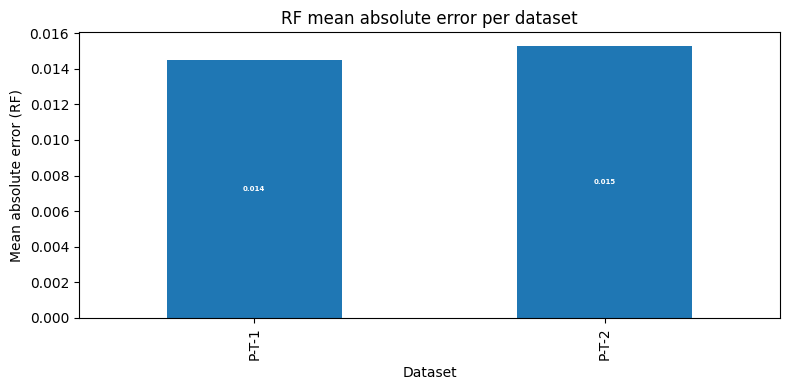

In [14]:
import matplotlib.pyplot as plt

df_all = load_all_tests(type_folder='triple') 
df_all = df_all[~df_all['dataset'].isin(['P-S-1'])]

# hitung mean absolute error RF per dataset
df_all["pred_abs_err"] = (df_all["RF_energy"] - df_all["ideal_energy"]).abs()
rf_means = df_all.groupby("dataset", observed=True)["pred_abs_err"].mean()
plt.figure(figsize=(8, 4))
rf_means.plot(kind="bar", color="tab:blue", capsize=5)

plt.ylabel("Mean absolute error (RF)")
plt.xlabel("Dataset")
plt.title("RF mean absolute error per dataset")

# tulis nilai di atas bar
for i, v in enumerate(rf_means):
    plt.text(i, v/2, f"{v:.3f}", ha="center", va="center",
             fontsize=5, fontweight="bold", color="white")

plt.tight_layout()
plt.show()


In [9]:
rf_table = load_all_tests('triple')
rf_table["pred_abs_err"] = (rf_table["RF_energy"] - rf_table["ideal_energy"]).abs()
rf_table = rf_table.groupby("dataset", observed=True)["pred_abs_err"].mean()

rf_table.sort_values()

dataset
P-T-1    0.028125
P-T-2    0.037941
Name: pred_abs_err, dtype: float64

Per Observable Analysis

In [13]:
obs = ['II', 'IZ', 'ZI', 'ZZ', 'XX']

In [14]:
import matplotlib.pyplot as plt

def obs_sens(type_filter='single', base_dir='../hasil_eksperimenV2_parity'):
    """
    type_filter: 'single', 'dual', atau 'all' (sesuai nama folder di gambar)
    """
    
    # 1. LOAD DATA
    # Langsung panggil fungsi load yang sudah disesuaikan strukturnya
    try:
        df_all = load_all_tests(type_folder=type_filter, base_dir=base_dir)
    except FileNotFoundError as e:
        print(e)
        return None

    # 2. FILTERING
    # a. Filter Observable
    df_all = df_all[df_all['observable'].isin(obs)]
    
    # b. Filter Dataset Tertentu (Opsional)
    # Jika ingin membuang 'J-S-1' (karena folder 01 biasanya dibuang di kode lama Anda):
    df_all = df_all[~df_all['dataset'].isin(['BK-S-1'])]

    if df_all.empty:
        print("Data kosong setelah difilter.")
        return None

    # 3. KALKULASI ERROR
    df_all["pred_abs_err"] = (df_all["RF_energy"] - df_all["ideal_energy"]).abs()
    

    # 4. GROUPING
    # Gunakan observed=True agar kategori 'J-S-1' yang dibuang tidak error/muncul kosong
    rf_means = df_all.groupby(["dataset", "observable"], observed=True)["pred_abs_err"].mean().reset_index()

    # 5. PLOTTING
    df_pivot = rf_means.pivot(index='dataset', columns='observable', values='pred_abs_err')
    
    plt.figure(figsize=(12, 6))
    for observable in df_pivot.columns:
        plt.plot(df_pivot.index, df_pivot[observable], marker='o', label=observable, linewidth=2)

    plt.title(f"Analisis Sensitivitas ({type_filter}): MAE per Observable", fontsize=14)
    plt.xlabel("Dataset", fontsize=12)
    plt.ylabel("Mean Absolute Error", fontsize=12)
    plt.legend(title="Observable", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.yscale('log')
    plt.xticks(rotation=45) # Putar label x agar J-S-xx tidak bertumpuk
    plt.show()

    return df_pivot


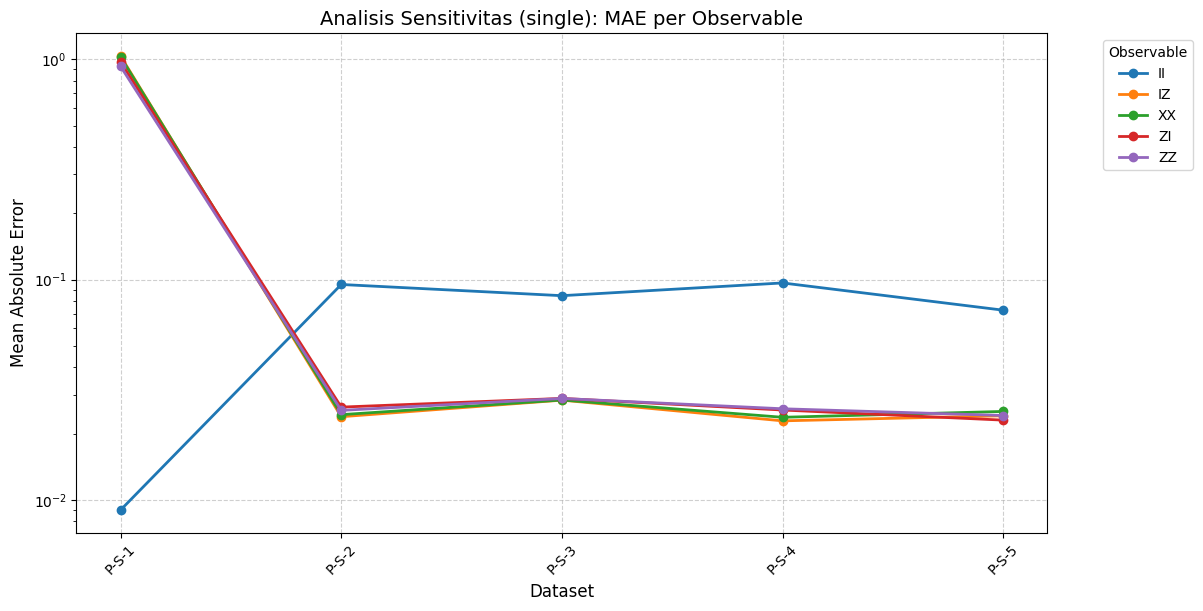

In [16]:
df_pivot_single = obs_sens()

In [17]:
import numpy as np

# Asumsi df_pivot adalah dataframe dari langkah sebelumnya
# baris = kondisi (02, 03...), kolom = observable

metrics = []

for col in df_pivot_single.columns:
    data = df_pivot_single[col]
    
    # 1. Hitung Sensitivitas (Rata-rata lompatan)
    sensitivity = data.diff().abs().mean()
    
    # 2. Hitung Fluktuasi Relatif (CV)
    cv = (data.std() / data.mean()) * 100
    
    # 3. Rentang (Max - Min) untuk melihat volatilitas ekstrem
    data_range = data.max() - data.min()
    
    metrics.append({
        'Observable': col,
        'Sensitivity (Avg Jump)': sensitivity,
        'Fluctuation (CV %)': cv,
        'Total Range': data_range
    })

df_metrics = pd.DataFrame(metrics).sort_values(by='Fluctuation (CV %)', ascending=False)
print(df_metrics)

  Observable  Sensitivity (Avg Jump)  Fluctuation (CV %)  Total Range
1         IZ                0.255330          199.155720     1.011053
2         XX                0.252497          198.366492     1.000420
3         ZI                0.238203          196.603914     0.947796
4         ZZ                0.227594          195.339482     0.903623
0         II                0.033101           50.676342     0.087519


Run VQE

In [18]:
import os
import pandas as pd
import re
def load_all_tests(type_folder, # Jadikan ini argumen wajib atau opsional
                   base_dir='../hasil_eksperimenV2_parity',
                   rel_path=('vqe_execution', 'vqe_results_multi_bond_length.csv')):
    
    # Gabungkan base_dir dengan type_folder
    full_base_path = os.path.join(base_dir, type_folder)
    
    # Fungsi pembantu untuk natural sorting
    def natural_key(text):
        return [int(c) if c.isdigit() else c for c in re.split(r'(\d+)', text)]

    dataframes = []
    
    # Pastikan folder ada sebelum listdir
    if not os.path.exists(full_base_path):
        raise FileNotFoundError(f"Folder tidak ditemukan: {full_base_path}")

    dir_list = sorted(os.listdir(full_base_path), key=natural_key)

    for test_dir in dir_list:
        csv_path = os.path.join(full_base_path, test_dir, *rel_path)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df['dataset'] = test_dir
            dataframes.append(df)
            
    if not dataframes:
        raise FileNotFoundError(f"Tidak ada file di {full_base_path}")

    full_df = pd.concat(dataframes, ignore_index=True)
    
    # Tetap gunakan categorical agar urutan J-S-1, J-S-2 dst tetap terjaga
    full_df['dataset'] = pd.Categorical(full_df['dataset'], categories=dir_list, ordered=True)
    
    return full_df

In [19]:
import numpy as np
import pandas as pd
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver

df = load_all_tests('single') 

bond_lengths = sorted(df["bond_length"].unique())

# fungsi hitung nuclear repulsion energy untuk H2 di jarak R (Angstrom)
def nuclear_repulsion_h2(R):
    driver = PySCFDriver(
        atom=f"H 0 0 0; H 0 0 {R}",
        basis="sto3g",
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    )
    problem = driver.run()
    # properti nuclear_repulsion_energy disediakan oleh ElectronicStructureProblem [web:13]
    return problem.nuclear_repulsion_energy

nre_list = []
for R in bond_lengths:
    nre = nuclear_repulsion_h2(R)
    nre_list.append({"bond_length": R, "nuclear_repulsion": nre})

nre_df = pd.DataFrame(nre_list)

# merge ke df VQE
df = df.merge(nre_df, on="bond_length", how="left")

# tambahkan total energy = electronic + nuclear_repulsion
# misalnya kamu mau untuk ideal_energy dan mitigated_energy
df["ideal_total_energy"] = df["ideal_energy"] + df["nuclear_repulsion"]
df["noisy_total_energy"] = df["noisy_energy"] + df["nuclear_repulsion"]
df["mitigated_total_energy"] = df["mitigated_energy"] + df["nuclear_repulsion"]


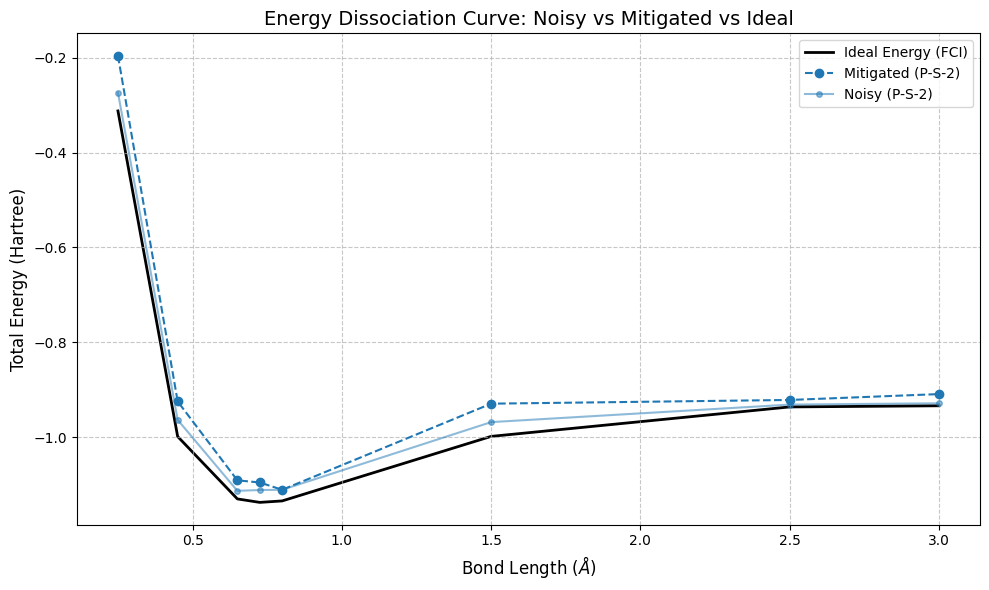

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Filter Data ---
wanted = ["P-S-2"]  # Ubah isi list ini sesuai keinginan
df_sel = df[df["dataset"].isin(wanted)].copy()

# === FIX PENTING: Hapus kategori yang tidak terpakai ===
if df_sel["dataset"].dtype.name == 'category':
    df_sel["dataset"] = df_sel["dataset"].cat.remove_unused_categories()

# Cek apakah data ada
if df_sel.empty:
    print(f"Data untuk dataset {wanted} tidak ditemukan.")
else:
    plt.figure(figsize=(10, 6))

    # --- 2. Plot Ideal Energy (Reference) ---
    ideal_data = df_sel[['bond_length', 'ideal_total_energy']].drop_duplicates(subset=['bond_length']).sort_values('bond_length')
    
    plt.plot(
        ideal_data["bond_length"],
        ideal_data["ideal_total_energy"],
        label="Ideal Energy (FCI)", 
        color="black",
        linestyle="-",
        linewidth=2,
        zorder=1 
    )

    # --- 3. Plot Mitigated & Noisy Energy (Looping) ---
    markers = ['o', 'x', '^', 's', 'D'] 
    
    for i, (name, group) in enumerate(df_sel.groupby("dataset", observed=True)):
        group = group.sort_values("bond_length")
        m = markers[i % len(markers)]
        
        # A. Plot Mitigated
        # Kita simpan objek 'line' ke variabel agar bisa mengambil warnanya
        line, = plt.plot(
            group["bond_length"],
            group["mitigated_total_energy"],
            label=f"Mitigated ({name})",
            linestyle="--",  # Garis putus-putus
            marker=m,
            markersize=6
        )
        
        # Ambil warna yang baru saja dipakai oleh plot mitigated
        current_color = line.get_color()

        # B. Plot Noisy (jika kolomnya ada)
        if "noisy_total_energy" in group.columns:
            plt.plot(
                group["bond_length"],
                group["noisy_total_energy"],
                label=f"Noisy ({name})",
                linestyle="-",      # Garis titik-titik
                marker=m,           # Marker sama
                markersize=4,       # Marker sedikit lebih kecil
                color=current_color, # Samakan warna dengan mitigated
                alpha=0.5           # Buat agak transparan
            )

    # --- 4. Kosmetik ---
    plt.xlabel("Bond Length ($\\AA$)", fontsize=12)
    plt.ylabel("Total Energy (Hartree)", fontsize=12)
    plt.title("Energy Dissociation Curve: Noisy vs Mitigated vs Ideal", fontsize=14)
    
    # Legend ditaruh di tempat terbaik
    plt.legend() 
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

other_var

In [13]:
def load_all_tests(base_dir='unified_output_v1',
                   rel_path=('ml_training', 'predict_data', 'predicted_data_1.csv')):
    """
    Membaca semua predicted_data_1.csv dari folder test_*
    dan mengembalikan satu DataFrame besar dengan kolom 'dataset'
    sebagai penanda asal folder (test_01, test_02, dst).
    """
    dataframes = []

    for test_dir in sorted(os.listdir(base_dir)):
        if not test_dir.startswith('pauli_'):
            continue

        csv_path = os.path.join(base_dir, test_dir, *rel_path)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df['dataset'] = test_dir   # penanda asal data
            dataframes.append(df)
        else:
            print(f"Peringatan: file tidak ditemukan: {csv_path}")

    if not dataframes:
        raise FileNotFoundError(
            "Tidak ada file predicted_data_1.csv yang ditemukan di folder test_*"
        )

    return pd.concat(dataframes, ignore_index=True)

# Contoh pemakaian:
df_all = load_all_tests()
print(df_all[['dataset', 'noisy_energy','RF_energy']].tail())

       dataset  noisy_energy  RF_energy
9995  pauli_05      0.992871   1.001960
9996  pauli_05      0.531202   0.587361
9997  pauli_05     -0.827355  -0.884796
9998  pauli_05      0.712270   0.767301
9999  pauli_05      0.248226   0.264095


In [88]:
pauli_var = [
    # One-body
    ["IIIZ", "IIZI", "IZII", "ZIII"],
    # Two-body diagonal (Z-only)
    ["IIZZ", "IZIZ", "IZZI", "ZIIZ", "ZIZI", "ZZII"],
    # Two-body off-diagonal (X/Y)
    ["XXXX", "YYYY", "XXYY", "YYXX"],
    # Variasi A: Z-only (zero_body + one_body + two_body_diagonal)
    [
        "IIII", "IIIZ", "IIZI", "IZII", "ZIII",
        "IIZZ", "IZIZ", "IZZI", "ZIIZ", "ZIZI", "ZZII",
    ],
    # Variasi B: Z + XXYY + YYXX
    [
        "IIII", "IIIZ", "IIZI", "IZII", "ZIII",
        "IIZZ", "IZIZ", "IZZI", "ZIIZ", "ZIZI", "ZZII",
        "XXYY", "YYXX",
    ],
]

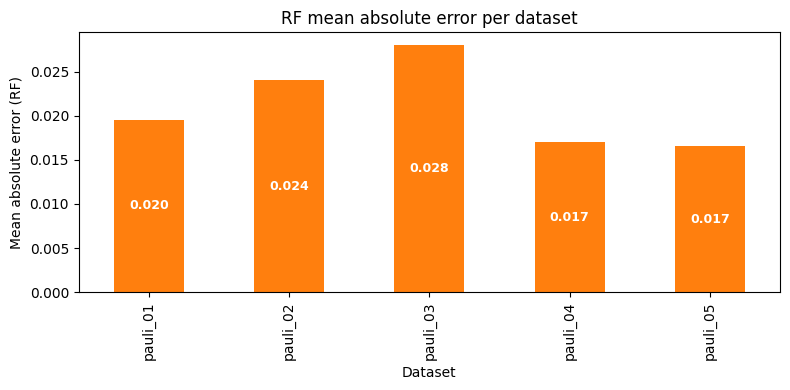

In [14]:
import matplotlib.pyplot as plt

# hitung mean absolute error RF per dataset
df_all["pred_abs_err"] = (df_all["RF_energy"] - df_all["ideal_energy"]).abs()
rf_means = df_all.groupby("dataset")["pred_abs_err"].mean()

plt.figure(figsize=(8, 4))
rf_means.plot(kind="bar", color="tab:orange")

plt.ylabel("Mean absolute error (RF)")
plt.xlabel("Dataset")
plt.title("RF mean absolute error per dataset")

# tulis nilai di atas bar
for i, v in enumerate(rf_means):
    plt.text(i, v/2, f"{v:.3f}", ha="center", va="center",
             fontsize=9, fontweight="bold", color="white")

plt.tight_layout()
plt.show()
